# ECG Model - 5 Second Segments
This experiment tests whether 5 seconds from each of the 4 channels is enough.
We train a new model from scratch and keep the 30-second model as a comparison.

Each patient gives us 6 segments, with APEX, LLSB, LUSB, and RUSB together in each
segment. The input is now `(4, 2500)`. The model already uses adaptive pooling,
so we can use the same architecture without changing the size of the final layer.

A steady heart rate makes this worth trying, but it doesn't tell us whether all
segments contain the same information. We will check both accuracy and agreement
between the 6 predictions. This is a separate experiment; the earlier notebooks
and model files stay as they are.

In [1]:
import os
import sys
import json
import random
import hashlib
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import display
from torch.utils.data import Dataset, DataLoader, SequentialSampler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    f1_score, balanced_accuracy_score,
)

PROJECT_DIR = os.path.abspath('..') if os.path.isdir('../src') else os.path.abspath('.')
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)
from src.preprocessing import load_raw_metadata, build_patient_metadata, preprocess_ecg, CHANNEL_ORDER, ECG_FS
from src.data_loader import ProcessedCardioDataset
from src.ecg_model import ECG_Encoder

# use the same seed and validation fold as the 30-second experiment
SEED = 42
VALIDATION_FOLD = 0
SEGMENT_SECONDS = 5
SEGMENT_SAMPLES = ECG_FS * SEGMENT_SECONDS
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

RAW_DIR = os.path.join(PROJECT_DIR, 'data/raw')
records_df, test_records_df = load_raw_metadata(RAW_DIR)
metadata = build_patient_metadata(records_df)
test_metadata = build_patient_metadata(test_records_df)

# split patients before making any segments
train_df = metadata[metadata['Fold'] != VALIDATION_FOLD].reset_index(drop=True)
val_df = metadata[metadata['Fold'] == VALIDATION_FOLD].reset_index(drop=True)
assert metadata['Patient_ID'].is_unique
assert set(train_df['Patient_ID']).isdisjoint(val_df['Patient_ID'])
assert set(metadata['Patient_ID']).isdisjoint(test_metadata['Patient_ID'])
assert set(train_df['Label']) == set(val_df['Label']) == {0, 1}

print(f"Training patients: {len(train_df)}")
print(f"Validation patients: {len(val_df)}")
print(f"Test patients: {len(test_metadata)}")

Training patients: 400
Validation patients: 100
Test patients: 120


## Preprocessing and Segmentation
We split the **raw ECG** first, then filter and normalize each 5-second segment.
This way, the model doesn't need information from the other 25 seconds to process
one segment. The filtering is still 0.5-40 Hz, followed by z-score normalization
for each channel. Short windows have more filter-edge effects, which is part of
what this experiment needs to test.

We use complete, non-overlapping windows. 30 seconds gives 6 windows, 12 seconds
gives 2 windows with the last 2 seconds discarded, and less than 5 seconds is rejected.
All 4 channels must have the same length and order. Different site recordings are
not necessarily aligned in time.

In [2]:
def load_patient_ecg(row):
    channels = []
    for channel in CHANNEL_ORDER:
        ecg, sample_rate = sf.read(row[f'{channel}_ECG_Path'], dtype='float32')
        if sample_rate != ECG_FS or ecg.ndim != 1:
            raise ValueError(f'{channel}: expected a mono ECG at {ECG_FS} Hz.')
        channels.append(ecg)
    if len({len(ecg) for ecg in channels}) != 1:
        raise ValueError('The 4 channels must have the same length.')
    return np.stack(channels)


def make_ecg_segments(ecg_raw, sample_rate=ECG_FS):
    ecg_raw = np.asarray(ecg_raw)
    if sample_rate != ECG_FS:
        raise ValueError(f'Expected {ECG_FS} Hz, got {sample_rate}.')
    if ecg_raw.ndim != 2 or ecg_raw.shape[0] != 4:
        raise ValueError('Expected (4, samples), ordered APEX, LLSB, LUSB, RUSB.')
    if not np.isfinite(ecg_raw).all():
        raise ValueError('ECG contains missing or nonfinite samples.')
    num_segments = ecg_raw.shape[1] // SEGMENT_SAMPLES
    if num_segments == 0:
        raise ValueError('At least 5 seconds from each channel is needed.')

    segments = []
    for segment_idx in range(num_segments):
        start = segment_idx * SEGMENT_SAMPLES
        end = start + SEGMENT_SAMPLES
        # crop first, then preprocess using only this window
        ecg_clean = preprocess_ecg(ecg_raw[:, start:end])
        segments.append(ecg_clean)
    return np.stack(segments)


class ECG5SecondDataset(Dataset):
    def __init__(self, patient_df):
        if patient_df.empty or not patient_df['Patient_ID'].is_unique:
            raise ValueError('Expected one row per patient before segmentation.')
        samples = []
        segment_records = []
        for _, row in tqdm(patient_df.iterrows(), total=len(patient_df), desc='Preparing 5-second ECGs'):
            segments = make_ecg_segments(load_patient_ecg(row))
            for segment_idx, ecg in enumerate(segments):
                samples.append(torch.from_numpy(ecg))
                segment_records.append({
                    'Patient_ID': row['Patient_ID'],
                    'Label': int(row['Label']),
                    'Fold': int(row['Fold']),
                    'Segment_Index': segment_idx,
                    'Start_Seconds': segment_idx * SEGMENT_SECONDS,
                    'End_Seconds': (segment_idx + 1) * SEGMENT_SECONDS,
                })
        # prepare once in memory, instead of filtering again every epoch
        self.ecg = torch.stack(samples)
        self.metadata = pd.DataFrame(segment_records)
        self.labels = torch.tensor(self.metadata['Label'].to_numpy(), dtype=torch.float32)

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        return self.ecg[idx], self.labels[idx]

Segment shape: (6, 4, 2500)


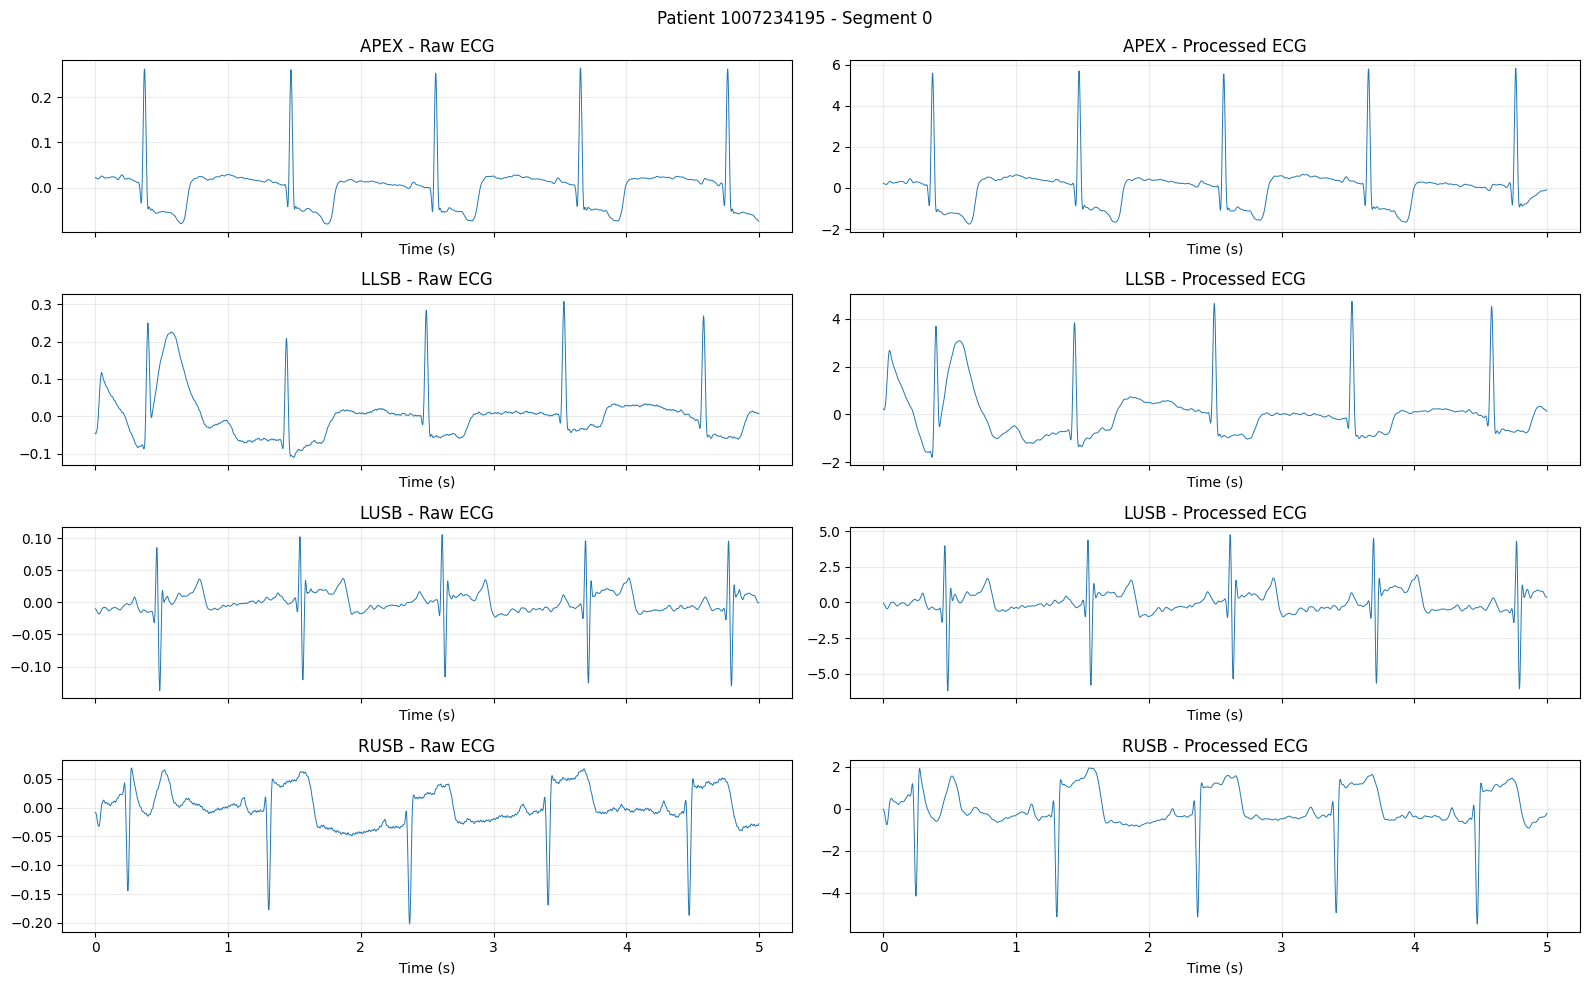

In [3]:
RECORD_NUMBER = 20  # <----- select the patient number
SEGMENT_NUMBER = 0 # <----- select segment 0 to 5
sample_patient = metadata.iloc[RECORD_NUMBER]
sample_raw = load_patient_ecg(sample_patient)
sample_segments = make_ecg_segments(sample_raw)

start = SEGMENT_NUMBER * SEGMENT_SAMPLES
end = start + SEGMENT_SAMPLES
t_ecg = np.arange(SEGMENT_SAMPLES) / ECG_FS
fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex=True)
for idx, channel in enumerate(CHANNEL_ORDER):
    axes[idx, 0].plot(t_ecg, sample_raw[idx, start:end], linewidth=0.7)
    axes[idx, 0].set_title(f'{channel} - Raw ECG')
    axes[idx, 1].plot(t_ecg, sample_segments[SEGMENT_NUMBER, idx], linewidth=0.7)
    axes[idx, 1].set_title(f'{channel} - Processed ECG')
    for ax in axes[idx]:
        ax.set_xlabel('Time (s)')
        ax.grid(True, alpha=0.25)
fig.suptitle(f"Patient {sample_patient['Patient_ID']} - Segment {SEGMENT_NUMBER}")
plt.tight_layout()
plt.show()
print(f'Segment shape: {sample_segments.shape}')

## Initialize Dataloaders and Model
Each training input is `(4, 2500)`, so a batch is `(batch_size, 4, 2500)`.
We use all 6 windows from every training patient. Each patient contributes the
same number of windows; these are still 400 patients, not 2400 independent people.

This is a new instance of `ECG_Encoder`, with new weights. We don't load the
30-second checkpoint into it.

In [4]:
batch_size = 16
train_dataset = ECG5SecondDataset(train_df)
val_dataset = ECG5SecondDataset(val_df)
for dataset in [train_dataset, val_dataset]:
    assert dataset.metadata.groupby('Patient_ID').size().eq(6).all()
assert set(train_dataset.metadata['Patient_ID']).isdisjoint(val_dataset.metadata['Patient_ID'])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0,
                          generator=torch.Generator().manual_seed(SEED), pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0,
                        pin_memory=torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_config = {'in_channels': 4, 'feature_dim': 128, 'dropout': 0.3}
ecg_model = ECG_Encoder(**model_config).to(device)
sample_ecg, sample_labels = next(iter(val_loader))
ecg_model.eval()
with torch.no_grad():
    sample_logits = ecg_model(sample_ecg.to(device))
assert sample_ecg.shape[1:] == (4, SEGMENT_SAMPLES)
assert sample_logits.shape == (len(sample_ecg), 1)

print(f'Training segments: {len(train_dataset)}')
print(f'Validation segments: {len(val_dataset)}')
print(f'Input shape: {sample_ecg.shape}; output shape: {sample_logits.shape}')
print(f'Model initialized on device: {device}')

Training segments: 2400
Validation segments: 600
Input shape: torch.Size([16, 4, 2500]); output shape: torch.Size([16, 1])
Model initialized on device: cuda


### Focal Loss
Focal Loss focuses on hard-to-classify examples, which is beneficial in our case with imbalanced classes. The formula is:
$$ FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t) $$
Where:
- $p_t$ is the model's estimated probability for the true class.
- $\alpha_t$ is the balancing factor for the true class.
- $\gamma$ is the focusing parameter that reduces the loss contribution from easy examples.

In [5]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.88, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        # standard BCE loss
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # get raw probabilities
        probs = torch.sigmoid(inputs)

        # pt is the probability of the true class
        pt = torch.where(targets == 1, probs, 1 - probs)

        # apply class weighting
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)

        # Focal Loss formula
        focal_loss = alpha_t * (1 - pt) ** self.gamma * bce_loss

        return focal_loss.mean()

## Training Loop
We keep the same focal loss, learning rate, batch size, AdamW, and early stopping
settings as the 30-second model. The class weight comes from training patients.

For checkpoint selection, we calculate validation AUROC separately at each of the
6 window positions and take their mean. That checks five-second predictions at
different points in the recording. We don't choose a checkpoint using the test set
or the averaged 30-second prediction.

An epoch now contains 6 times as many inputs and optimizer steps. This is an
experiment with five-second training, not a controlled comparison of window length
alone. We save the new checkpoint in its own folder.

In [6]:
MODEL_DIR = os.path.join(PROJECT_DIR, 'models', 'ecg_5s', f'fold{VALIDATION_FOLD}_seed{SEED}')
os.makedirs(MODEL_DIR, exist_ok=True) # create models directory if it doesn't exist

# manually set hyperparameters
num_epochs = 50
learning_rate = 1e-3
weight_decay = 1e-4
patience = 10

# initialize Focal Loss instead of BCEWithLogitsLoss
focal_alpha = float((train_df['Label'] == 0).mean())
criterion = FocalLoss(alpha=focal_alpha, gamma=2.0).to(device)
optimizer = optim.AdamW(ecg_model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_auroc = -float('inf')
epochs_without_improvement = 0
history = []
MODEL_SAVE_PATH = os.path.join(MODEL_DIR, 'best_ecg_5s.pt')

# keep the dropout seed the same when starting a training run
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

for epoch in range(num_epochs):
    # training
    ecg_model.train()
    train_loss = 0.0

    for ecg, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        ecg = ecg.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)
        outputs = ecg_model(ecg)
        loss = criterion(outputs, labels)

        if not torch.isfinite(loss):
            raise ValueError("Training loss is not finite.")
        loss.backward()
        nn.utils.clip_grad_norm_(ecg_model.parameters(), max_norm=1.0, error_if_nonfinite=True)
        optimizer.step()
        train_loss += loss.item() * ecg.size(0)

    epoch_train_loss = train_loss / len(train_loader.dataset)

    # validation
    ecg_model.eval()
    val_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for ecg, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            ecg = ecg.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = ecg_model(ecg)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * ecg.size(0)

            # sigmoid to convert raw logits to probabilities
            preds = torch.sigmoid(outputs)
            all_labels.extend(labels.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())

    epoch_val_loss = val_loss / len(val_loader.dataset)

    # calculate metrics
    val_segments = val_dataset.metadata.copy()
    val_segments['Score'] = all_preds
    position_aurocs = []
    position_auprcs = []
    for _, group in val_segments.groupby('Segment_Index'):
        position_aurocs.append(roc_auc_score(group['Label'], group['Score']))
        position_auprcs.append(average_precision_score(group['Label'], group['Score']))
    auroc = float(np.mean(position_aurocs))
    auprc = float(np.mean(position_auprcs))

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUROC: {auroc:.4f} | AUPRC: {auprc:.4f}")

    history.append({
        'epoch': epoch + 1,
        'train_loss': epoch_train_loss,
        'val_loss': epoch_val_loss,
        'val_auroc': auroc,
        'val_auprc': auprc,
        'lr': optimizer.param_groups[0]['lr'],
    })
    scheduler.step(auroc)

    # save model if AUROC improves
    if auroc > best_auroc:
        print(f"Validation AUROC improved from {best_auroc:.4f} to {auroc:.4f}. Saving improved model.")
        best_auroc = auroc
        epochs_without_improvement = 0
        torch.save(ecg_model.state_dict(), MODEL_SAVE_PATH) # save state_dict() instead of the whole model
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping. Best validation AUROC: {best_auroc:.4f}")
            break

# keep the best weights for evaluation
ecg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
ecg_model.eval()

history = pd.DataFrame(history)
history.to_csv(MODEL_SAVE_PATH.replace('.pt', '.history.csv'), index=False)

Epoch 1 | Train Loss: 0.0334 | Val Loss: 0.0341 | AUROC: 0.8463 | AUPRC: 0.3737
Validation AUROC improved from -inf to 0.8463. Saving improved model.
Epoch 2 | Train Loss: 0.0256 | Val Loss: 0.0273 | AUROC: 0.8810 | AUPRC: 0.4063
Validation AUROC improved from 0.8463 to 0.8810. Saving improved model.
Epoch 3 | Train Loss: 0.0251 | Val Loss: 0.0345 | AUROC: 0.8703 | AUPRC: 0.4618
Epoch 4 | Train Loss: 0.0222 | Val Loss: 0.0268 | AUROC: 0.8733 | AUPRC: 0.4910
Epoch 5 | Train Loss: 0.0212 | Val Loss: 0.0190 | AUROC: 0.9074 | AUPRC: 0.5235
Validation AUROC improved from 0.8810 to 0.9074. Saving improved model.
Epoch 6 | Train Loss: 0.0190 | Val Loss: 0.0262 | AUROC: 0.9130 | AUPRC: 0.5328
Validation AUROC improved from 0.9074 to 0.9130. Saving improved model.
Epoch 7 | Train Loss: 0.0186 | Val Loss: 0.0229 | AUROC: 0.9004 | AUPRC: 0.5106
Epoch 8 | Train Loss: 0.0184 | Val Loss: 0.0264 | AUROC: 0.8902 | AUPRC: 0.5228
Epoch 9 | Train Loss: 0.0152 | Val Loss: 0.0233 | AUROC: 0.9064 | AUPRC: 0

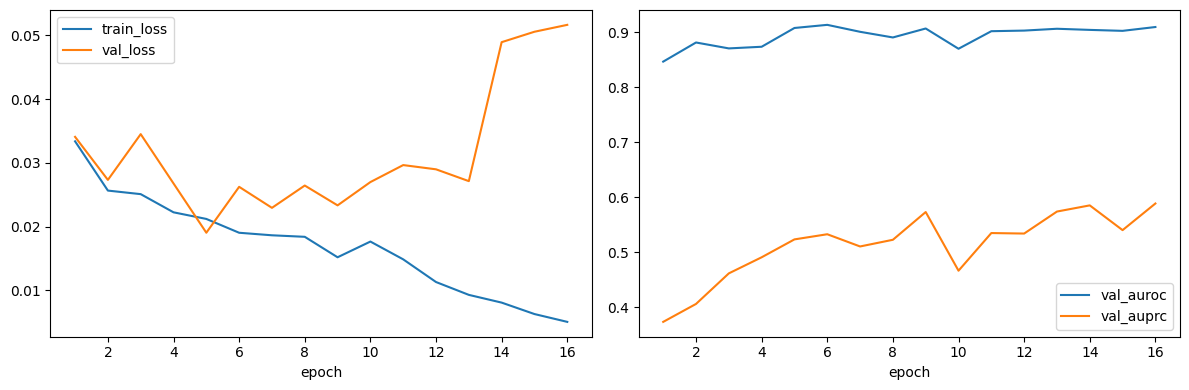

In [7]:
# plot the training and validation results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history.plot(x='epoch', y=['train_loss', 'val_loss'], ax=axes[0])
history.plot(x='epoch', y=['val_auroc', 'val_auprc'], ax=axes[1])
plt.tight_layout()
plt.show()

## Model Evaluation
First we collect a score for every validation segment. We choose one threshold
for individual five-second predictions using all validation windows. Every patient
has 6 windows, so patients contribute equally. We also choose a separate threshold
for the mean of all 6 scores. Both thresholds are frozen before testing.

We report the first 5 seconds, each other position, the first 10 seconds averaged,
and all 30 seconds averaged. For majority voting, a tie uses the averaged-score
decision. Agreement by itself doesn't mean the answer is right, so we show it
alongside accuracy and class-specific results.

In [8]:
@torch.no_grad()
def predict_segments(model, loader):
    if not isinstance(loader.sampler, SequentialSampler):
        raise ValueError('Prediction loader must use shuffle=False to keep patient IDs in order.')
    model.eval()
    scores = []
    for ecg, labels in loader:
        preds = torch.sigmoid(model(ecg.to(device)))
        scores.extend(preds.cpu().numpy().ravel())
    result = loader.dataset.metadata.copy()
    result['Score'] = scores
    assert np.isfinite(result['Score']).all()
    return result


def best_f1_threshold(labels, scores):
    precision, recall, thresholds = precision_recall_curve(labels, scores)
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)
    return float(thresholds[np.argmax(f1)])


def patient_scores(segments, num_windows=None):
    selected = segments if num_windows is None else segments[segments['Segment_Index'] < num_windows]
    return selected.groupby('Patient_ID', sort=False).agg(Label=('Label', 'first'), Score=('Score', 'mean'))


def metric_row(name, labels, scores, threshold, predictions=None):
    labels, scores = np.asarray(labels), np.asarray(scores)
    predictions = (scores >= threshold).astype(int) if predictions is None else np.asarray(predictions)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        'Method': name, 'Patients': len(labels), 'HFrEF': int(labels.sum()),
        'AUROC': roc_auc_score(labels, scores), 'AUPRC': average_precision_score(labels, scores),
        'F1': f1_score(labels, predictions, zero_division=0),
        'Sensitivity': tp / (tp + fn), 'Specificity': tn / (tn + fp),
        'Balanced_Accuracy': balanced_accuracy_score(labels, predictions),
        'Threshold': threshold, 'TP': int(tp), 'FN': int(fn), 'FP': int(fp), 'TN': int(tn),
    }


def compare_windows(segments, thresholds):
    rows = []
    for index, group in segments.groupby('Segment_Index'):
        rows.append(metric_row(f'{index * 5}-{(index + 1) * 5}s only', group['Label'], group['Score'], thresholds['single']))
    for count, key in [(2, 'mean2'), (6, 'mean6')]:
        patients = patient_scores(segments, count)
        rows.append(metric_row(f'Mean of {count} windows ({count * 5}s)', patients['Label'], patients['Score'], thresholds[key]))

    # strict majority; if half the windows vote positive, use the mean-score decision
    votes = segments.assign(Vote=(segments['Score'] >= thresholds['single']).astype(int))
    patients = votes.groupby('Patient_ID', sort=False).agg(
        Label=('Label', 'first'), Score=('Score', 'mean'), Votes=('Vote', 'sum'), Windows=('Vote', 'size'))
    tied = patients['Votes'] * 2 == patients['Windows']
    predictions = (patients['Votes'] * 2 > patients['Windows']).astype(int)
    predictions.loc[tied] = (patients.loc[tied, 'Score'] >= thresholds['mean6']).astype(int)
    row = metric_row('Majority vote (30s; mean breaks ties)', patients['Label'],
                     patients['Votes'] / patients['Windows'], 0.5, predictions)
    row['Ties'] = int(tied.sum())
    rows.append(row)
    return pd.DataFrame(rows)


def window_consistency(segments, threshold):
    scores = segments.pivot(index='Patient_ID', columns='Segment_Index', values='Score')
    assert scores.shape[1] == 6 and not scores.isna().any().any()
    labels = segments.groupby('Patient_ID')['Label'].first().reindex(scores.index)
    predictions = scores >= threshold
    result = pd.DataFrame({
        'Label': labels,
        'Score_Mean': scores.mean(axis=1),
        'Score_Std': scores.std(axis=1, ddof=0),
        'Score_Range': scores.max(axis=1) - scores.min(axis=1),
        'Positive_Windows': predictions.sum(axis=1),
        'Correct_Windows': predictions.eq(labels.astype(bool), axis=0).sum(axis=1),
    })
    result['All_Agree'] = result['Positive_Windows'].isin([0, 6])
    return result

In [9]:
ecg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
val_predictions = predict_segments(ecg_model, val_loader)
thresholds = {'single': best_f1_threshold(val_predictions['Label'], val_predictions['Score'])}
for count, key in [(2, 'mean2'), (6, 'mean6')]:
    patients = patient_scores(val_predictions, count)
    thresholds[key] = best_f1_threshold(patients['Label'], patients['Score'])

print('Frozen validation thresholds:', thresholds)
validation_results = compare_windows(val_predictions, thresholds)
display(validation_results.round(4))
val_consistency = window_consistency(val_predictions, thresholds['single'])
display(val_consistency.groupby('Label').agg(
    Patients=('All_Agree', 'size'), All_6_Agree=('All_Agree', 'mean'),
    Mean_Correct_Windows=('Correct_Windows', 'mean'), Mean_Score_Std=('Score_Std', 'mean')))

Frozen validation thresholds: {'single': 0.41620755195617676, 'mean2': 0.39662402868270874, 'mean6': 0.546824038028717}


,Method,Patients,HFrEF,AUROC,AUPRC,F1,Sensitivity,Specificity,Balanced_Accuracy,Threshold,TP,FN,FP,TN,Ties
0,0-5s only,100,12,0.8845,0.4776,0.6061,0.8333,0.8750,0.8542,0.4162,10,2,11,77,NaN
1,5-10s only,100,12,0.9129,0.5217,0.5882,0.8333,0.8636,0.8485,0.4162,10,2,12,76,NaN
2,10-15s only,100,12,0.9176,0.6405,0.6061,0.8333,0.8750,0.8542,0.4162,10,2,11,77,NaN
3,15-20s only,100,12,0.9148,0.5448,0.6061,0.8333,0.8750,0.8542,0.4162,10,2,11,77,NaN
4,20-25s only,100,12,0.9233,0.4952,0.5946,0.9167,0.8409,0.8788,0.4162,11,1,14,74,NaN
5,25-30s only,100,12,0.9252,0.5171,0.6250,0.8333,0.8864,0.8598,0.4162,10,2,10,78,NaN
6,Mean of 2 windows (10s),100,12,0.9091,0.5001,0.6061,0.8333,0.8750,0.8542,0.3966,10,2,11,77,NaN
7,Mean of 6 windows (30s),100,12,0.9252,0.5666,0.6207,0.7500,0.9091,0.8295,0.5468,9,3,8,80,NaN
8,Majority vote (30s; mean breaks ties),100,12,0.9015,0.5152,0.6250,0.8333,0.8864,0.8598,0.5000,10,2,10,78,2.0


,Patients,All_6_Agree,Mean_Correct_Windows,Mean_Score_Std
Label,,,,
0,88,0.886364,5.215909,0.050324
1,12,0.833333,5.083333,0.048688


## Using The Test Set
Now we use the frozen model and thresholds on the separate test patients.
These results are for reporting, not for choosing another checkpoint or changing
the thresholds. The test set has only 5 HFrEF patients, so one missed patient
changes sensitivity by 20 percentage points.

,Method,Patients,HFrEF,AUROC,AUPRC,F1,Sensitivity,Specificity,Balanced_Accuracy,Threshold,TP,FN,FP,TN,Ties
0,0-5s only,120,5,0.9200,0.4660,0.2857,0.8,0.8348,0.8174,0.4162,4,1,19,96,NaN
1,5-10s only,120,5,0.9357,0.4312,0.4000,0.8,0.9043,0.8522,0.4162,4,1,11,104,NaN
2,10-15s only,120,5,0.9670,0.7310,0.3810,0.8,0.8957,0.8478,0.4162,4,1,12,103,NaN
3,15-20s only,120,5,0.9635,0.7204,0.4167,1.0,0.8783,0.9391,0.4162,5,0,14,101,NaN
4,20-25s only,120,5,0.9739,0.5603,0.4762,1.0,0.9043,0.9522,0.4162,5,0,11,104,NaN
5,25-30s only,120,5,0.9896,0.8909,0.5263,1.0,0.9217,0.9609,0.4162,5,0,9,106,NaN
6,Mean of 2 windows (10s),120,5,0.9304,0.4939,0.3636,0.8,0.8870,0.8435,0.3966,4,1,13,102,NaN
7,Mean of 6 windows (30s),120,5,0.9739,0.7889,0.6154,0.8,0.9652,0.8826,0.5468,4,1,4,111,NaN
8,Majority vote (30s; mean breaks ties),120,5,0.9661,0.4181,0.4706,0.8,0.9304,0.8652,0.5000,4,1,8,107,4.0


,Patients,All_6_Agree,Mean_Correct_Windows,Mean_Score_Std
Label,,,,
0,115,0.8,5.33913,0.060510
1,5,0.8,5.40000,0.057782


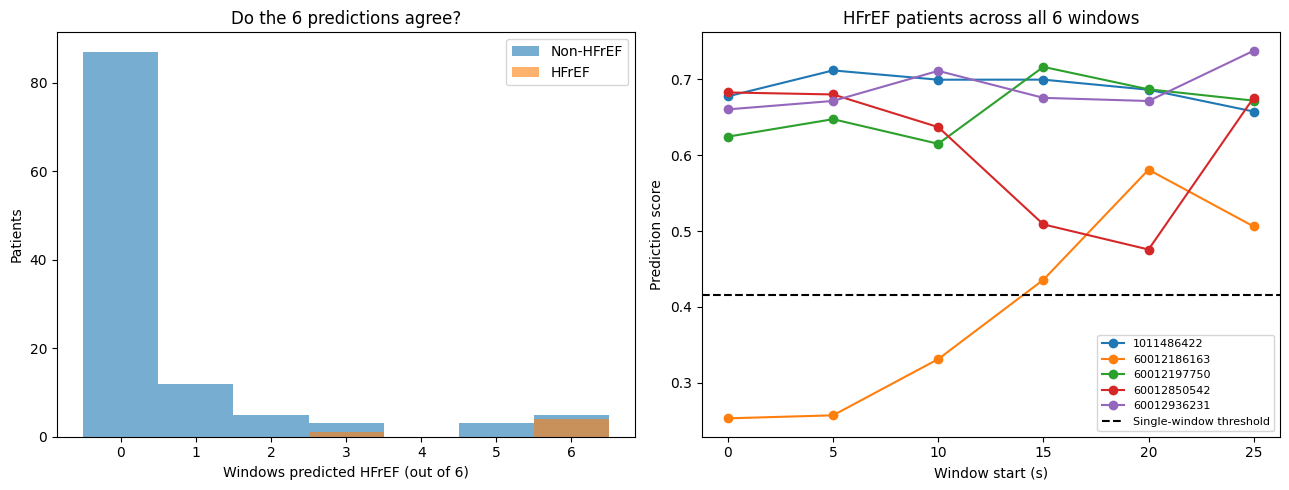

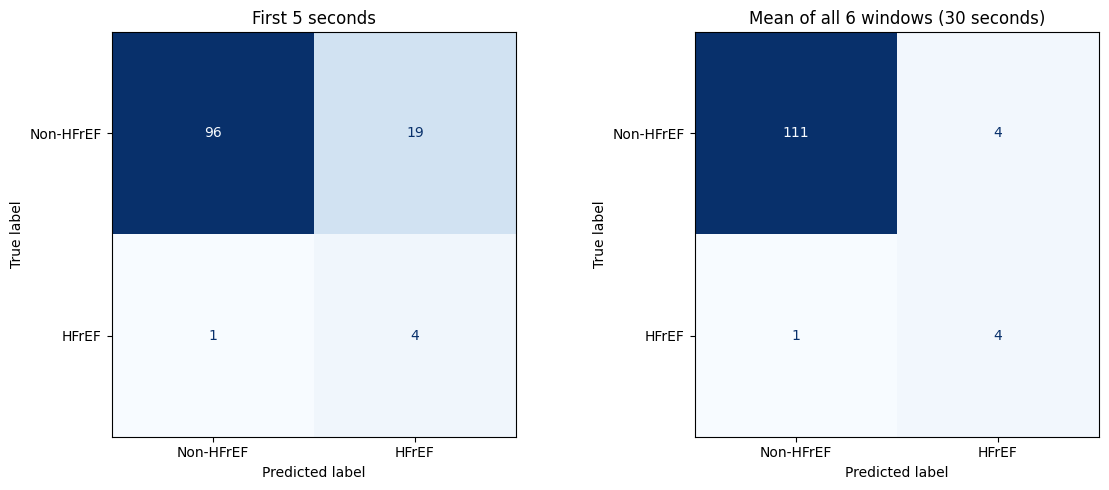

In [10]:
test_dataset = ECG5SecondDataset(test_metadata)
assert test_dataset.metadata.groupby('Patient_ID').size().eq(6).all()
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0,
                         pin_memory=torch.cuda.is_available())
test_predictions = predict_segments(ecg_model, test_loader)
test_results = compare_windows(test_predictions, thresholds)
test_consistency = window_consistency(test_predictions, thresholds['single'])
display(test_results.round(4))
display(test_consistency.groupby('Label').agg(
    Patients=('All_Agree', 'size'), All_6_Agree=('All_Agree', 'mean'),
    Mean_Correct_Windows=('Correct_Windows', 'mean'), Mean_Score_Std=('Score_Std', 'mean')))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, name in [(0, 'Non-HFrEF'), (1, 'HFrEF')]:
    values = test_consistency[test_consistency['Label'] == label]['Positive_Windows']
    axes[0].hist(values, bins=np.arange(-0.5, 7.5), alpha=0.6, label=name)
axes[0].set_xlabel('Windows predicted HFrEF (out of 6)')
axes[0].set_ylabel('Patients')
axes[0].set_title('Do the 6 predictions agree?')
axes[0].legend()

patient_matrix = test_predictions.pivot(index='Patient_ID', columns='Segment_Index', values='Score')
for patient_id in test_consistency[test_consistency['Label'] == 1].index:
    axes[1].plot(np.arange(6) * 5, patient_matrix.loc[patient_id], marker='o', label=patient_id)
axes[1].axhline(thresholds['single'], color='black', linestyle='--', label='Single-window threshold')
axes[1].set_xlabel('Window start (s)')
axes[1].set_ylabel('Prediction score')
axes[1].set_title('HFrEF patients across all 6 windows')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

first_window = test_predictions[test_predictions['Segment_Index'] == 0]
mean_patients = patient_scores(test_predictions)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, frame, cutoff, title in [
    (axes[0], first_window, thresholds['single'], 'First 5 seconds'),
    (axes[1], mean_patients, thresholds['mean6'], 'Mean of all 6 windows (30 seconds)'),
]:
    cm = confusion_matrix(frame['Label'], frame['Score'] >= cutoff, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=['Non-HFrEF', 'HFrEF']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Comparing with the 30-Second Model
We load the existing 30-second checkpoint and its saved threshold. It must have
the same training and validation patient IDs. This model still receives the full
30-second preprocessed ECG. We don't retrain it or change its threshold.

In [11]:
baseline_path = os.path.join(PROJECT_DIR, 'models', f'best_ecg_4ch_fold{VALIDATION_FOLD}.pt')
baseline_settings_path = baseline_path.replace('.pt', '.json')
baseline_results = []
baseline_hash = None
if os.path.isfile(baseline_path) and os.path.isfile(baseline_settings_path):
    with open(baseline_settings_path) as f:
        baseline_settings = json.load(f)
    assert set(baseline_settings['train_patient_ids']) == set(train_df['Patient_ID'])
    assert set(baseline_settings['validation_patient_ids']) == set(val_df['Patient_ID'])
    assert baseline_settings['channel_order'] == list(CHANNEL_ORDER)
    assert baseline_settings['ecg_samples'] == 15000
    baseline_model = ECG_Encoder(**baseline_settings['model_config']).to(device)
    baseline_model.load_state_dict(torch.load(baseline_path, map_location=device, weights_only=True))
    baseline_model.eval()
    with open(baseline_path, 'rb') as f:
        baseline_hash = hashlib.sha256(f.read()).hexdigest()
    for split, patient_ids, directory in [
        ('Validation', val_df['Patient_ID'], 'development'),
        ('Test', test_metadata['Patient_ID'], 'test'),
    ]:
        data_dir = os.path.join(PROJECT_DIR, 'data/processed/patient_4ch', directory)
        saved_df = pd.read_csv(os.path.join(data_dir, 'processed_metadata.csv'), dtype={'Patient_ID': str})
        saved_df = saved_df[saved_df['Patient_ID'].isin(patient_ids)].reset_index(drop=True)
        assert set(saved_df['Patient_ID']) == set(patient_ids)
        loader = DataLoader(ProcessedCardioDataset(saved_df, data_dir, modality='ecg'),
                            batch_size=batch_size, shuffle=False)
        scores = []
        with torch.no_grad():
            for ecg, labels in loader:
                scores.extend(torch.sigmoid(baseline_model(ecg.to(device))).cpu().numpy().ravel())
        row = metric_row('Original 30-second model', saved_df['Label'], scores, baseline_settings['threshold'])
        row['Split'] = split
        baseline_results.append(row)
else:
    print('No matching 30-second checkpoint/settings found. The 5-second results are still available above.')

comparison = pd.concat([
    validation_results.assign(Split='Validation'),
    test_results.assign(Split='Test'),
    pd.DataFrame(baseline_results),
], ignore_index=True)
display(comparison[['Split', 'Method', 'AUROC', 'AUPRC', 'F1', 'Sensitivity', 'Specificity']].round(4))

,Split,Method,AUROC,AUPRC,F1,Sensitivity,Specificity
0,Validation,0-5s only,0.8845,0.4776,0.6061,0.8333,0.8750
1,Validation,5-10s only,0.9129,0.5217,0.5882,0.8333,0.8636
2,Validation,10-15s only,0.9176,0.6405,0.6061,0.8333,0.8750
3,Validation,15-20s only,0.9148,0.5448,0.6061,0.8333,0.8750
4,Validation,20-25s only,0.9233,0.4952,0.5946,0.9167,0.8409
5,Validation,25-30s only,0.9252,0.5171,0.6250,0.8333,0.8864
6,Validation,Mean of 2 windows (10s),0.9091,0.5001,0.6061,0.8333,0.8750
7,Validation,Mean of 6 windows (30s),0.9252,0.5666,0.6207,0.7500,0.9091
8,Validation,Majority vote (30s; mean breaks ties),0.9015,0.5152,0.6250,0.8333,0.8864
9,Test,0-5s only,0.9200,0.4660,0.2857,0.8000,0.8348


## Trying Different Input Lengths
This uses the new model on raw ECG arrays shaped `(4, samples)` at 500 Hz.
The function splits, preprocesses, predicts, and combines the results. For this
experiment, thresholds have been checked for 1, 2, and 6 windows. Other counts
need their own validation before we attach a final binary label.

In [12]:
@torch.no_grad()
def predict_recording(ecg_raw, sample_rate=ECG_FS):
    segments = make_ecg_segments(ecg_raw, sample_rate)
    ecg_model.eval()
    scores = []
    for start in range(0, len(segments), batch_size):
        batch = torch.from_numpy(segments[start:start + batch_size]).to(device)
        scores.extend(torch.sigmoid(ecg_model(batch)).cpu().numpy().ravel())
    count = len(scores)
    key = {1: 'single', 2: 'mean2', 6: 'mean6'}.get(count)
    cutoff = thresholds[key] if key else None
    return {
        'Windows': count,
        'Used_Seconds': count * SEGMENT_SECONDS,
        'Discarded_Seconds': (np.asarray(ecg_raw).shape[1] - count * SEGMENT_SAMPLES) / sample_rate,
        'Window_Scores': [float(score) for score in scores],
        'Mean_Score': float(np.mean(scores)),
        'Threshold': cutoff,
        'Prediction': int(np.mean(scores) >= cutoff) if cutoff is not None else None,
    }


# use a validation patient for the input-length example
example_ecg = load_patient_ecg(val_df.iloc[0])
for seconds in [5, 12, 30]:
    result = predict_recording(example_ecg[:, :seconds * ECG_FS])
    print(f'{seconds} seconds:', result)
    assert result['Windows'] == seconds // 5
    assert result['Discarded_Seconds'] == seconds % 5

5 seconds: {'Windows': 1, 'Used_Seconds': 5, 'Discarded_Seconds': 0.0, 'Window_Scores': [0.18482021987438202], 'Mean_Score': 0.18482021987438202, 'Threshold': 0.41620755195617676, 'Prediction': 0}
12 seconds: {'Windows': 2, 'Used_Seconds': 10, 'Discarded_Seconds': 2.0, 'Window_Scores': [0.1848202496767044, 0.3400658369064331], 'Mean_Score': 0.26244303584098816, 'Threshold': 0.39662402868270874, 'Prediction': 0}
30 seconds: {'Windows': 6, 'Used_Seconds': 30, 'Discarded_Seconds': 0.0, 'Window_Scores': [0.1848202496767044, 0.3400658369064331, 0.2631599009037018, 0.10136464238166809, 0.25397518277168274, 0.2686978280544281], 'Mean_Score': 0.23534727096557617, 'Threshold': 0.546824038028717, 'Prediction': 0}


In [13]:
# save the settings, predictions and comparisons next to the new model
experiment = {
    'model_config': model_config, 'channel_order': list(CHANNEL_ORDER),
    'ecg_sample_rate': ECG_FS, 'segment_seconds': SEGMENT_SECONDS,
    'segment_samples': SEGMENT_SAMPLES, 'preprocessing': 'crop raw window, then 0.5-40 Hz filter and per-channel z-score',
    'seed': SEED, 'validation_fold': VALIDATION_FOLD,
    'max_epochs': num_epochs, 'epochs_run': len(history),
    'best_epoch': int(history.loc[history['val_auroc'].idxmax(), 'epoch']),
    'selection_metric': 'mean validation AUROC across six window positions',
    'thresholds': thresholds, 'focal_alpha': focal_alpha, 'focal_gamma': 2.0,
    'learning_rate': learning_rate, 'weight_decay': weight_decay, 'patience': patience,
    'batch_size': batch_size, 'train_patient_ids': train_df['Patient_ID'].tolist(),
    'validation_patient_ids': val_df['Patient_ID'].tolist(),
    'baseline_checkpoint_sha256': baseline_hash,
}
with open(MODEL_SAVE_PATH.replace('.pt', '.json'), 'w') as f:
    json.dump(experiment, f, indent=2)
for name, frame in [
    ('validation_segments', val_predictions), ('test_segments', test_predictions),
    ('validation_consistency', val_consistency.reset_index()),
    ('test_consistency', test_consistency.reset_index()), ('comparison', comparison),
]:
    frame.to_csv(os.path.join(MODEL_DIR, name + '.csv'), index=False)
print(f'Results saved in {MODEL_DIR}')

Results saved in E:\Deep Learning\CardioFusion\models\ecg_5s\fold0_seed42


## Observations on the results:
### Experiment 4: 5-second segments
With a new model trained from scratch, all 4 channels, 5-second segments, Focal Loss, and no overlap. These notes are from **fold 0, seed 42**.

- The model does learn from 5 seconds. The best mean validation AUROC across the 6 window positions was **0.9130**, at **epoch 6**. Training stopped after **16 epochs**. So the smaller input works with the architecture, and the predictions are doing something useful.
- It hasn't matched the 30-second model. On validation patients, the first 5 seconds had **AUROC 0.8845**, compared with **0.9564** for the original model. Averaging all 6 windows reached **0.9252**, which still uses 30 seconds of data.

#### Test Results
There are 120 test patients, including 5 with HFrEF. The thresholds below were selected on validation patients and kept fixed for testing.

| Method | AUROC | AUPRC | F1 | HFrEF caught | False positives |
|---|---:|---:|---:|---:|---:|
| First 5 seconds | 0.9200 | 0.4660 | 0.2857 | 4/5 | 19 |
| Mean of 2 windows (10s) | 0.9304 | 0.4939 | 0.3636 | 4/5 | 13 |
| Mean of 6 windows (30s) | 0.9739 | 0.7889 | 0.6154 | 4/5 | 4 |
| Majority vote (30s) | 0.9661 | 0.4181 | 0.4706 | 4/5 | 8 |
| Original 30-second model | 0.9983 | 0.9667 | 0.7143 | 5/5 | 4 |

- **Averaging helps in this run**, but it doesn't make one 5-second prediction equivalent to the original model. The first window missed 1 HFrEF patient and gave 19 false positives. Averaging 6 windows still missed that patient, but reduced false positives to 4. Part of this difference comes from using a separate validation threshold for the averaged score. Its higher AUROC also shows better ranking across patients.
- **The predictions are mostly consistent, but not identical.** All 6 binary predictions agreed for **96/120 test patients (80%)**, and for **88/100 validation patients (88%)**. On the test set, 87 Non-HFrEF patients were negative in every window and 4 HFrEF patients were positive in every window. However, 5 Non-HFrEF patients were wrong in every window. Agreement alone is not enough.
- One HFrEF patient changed from negative in the first 3 windows to positive in the last 3. Test AUROC also varied from **0.9200 to 0.9896** across window positions. The first window was the weakest on both validation and test data. This shows why a repeating heartbeat doesn't guarantee the same prediction from every 5 seconds. We shouldn't choose the last window just because it scored best on this test set.
- Majority voting was weaker than averaging here: **F1 0.4706 vs 0.6154**, with 8 false positives instead of 4. Averaging keeps the score values instead of converting each one into a vote first. These methods also use different decision rules, so this result doesn't prove averaging will always win.

#### Why might 5 seconds lose some performance?
- There are fewer beats and less time to average out noise. The network sees waveform shape and all 4 channels, not just BPM. A steady rate doesn't mean the waveform, noise, or useful features stay identical.
- Filtering and normalization now happen inside each 5-second window. This is needed for a real 5-second input, but filter edges take up more of the input, and the normalization and pooling statistics differ from the 30-second setup. The first-window result could also reflect recording-start quality. These are possible explanations; this experiment didn't isolate which one caused the difference.
- More training didn't fix it. Training loss kept falling after epoch 6, but the mean validation AUROC didn't improve, and validation loss eventually increased. That suggests overfitting rather than simply needing more epochs.
- Segmentation gave us 2400 training windows, but still only 400 training patients. It also gave each epoch 6 times as many optimizer steps. This is not a comparison where only the input length changed.

#### What to do next
For now, I would keep the original 30-second model as the main model. The 5-second model is a useful starting point if shorter recordings are needed, but it currently gives more false positives and its answer can depend on the window.